# The Wavelet Transform

A hands-on walkthrough: from intuition to denoising real EEG signals.

---
## 1. What is a Wavelet?

Wavelets are short, oscillatory waveforms that **decay rapidly to zero**. Unlike infinite sine waves (Fourier), wavelets are localised in both time and frequency.

| Property | Fourier (sine/cosine) | Wavelet |
|---|---|---|
| Duration | Infinite | Finite (compact support) |
| Window | Fixed for all frequencies | Adaptive (narrow at high-f, wide at low-f) |
| Best for | Stationary signals | Transient signals (spikes, edges, bursts) |

### Core Properties
1. **Finite Energy** — the wavelet has bounded total energy: $\int |\psi(t)|^2\,dt < \infty$
2. **Zero Mean** — integrates to zero: $\int \psi(t)\,dt = 0$ (oscillatory, no DC)
3. **Centred at Zero** — concentrated around $t = 0$, decays on both sides

![WhatsApp Image 2026-05-14 at 5.37.13 PM.jpeg](<attachment:WhatsApp Image 2026-05-14 at 5.37.13 PM.jpeg>)
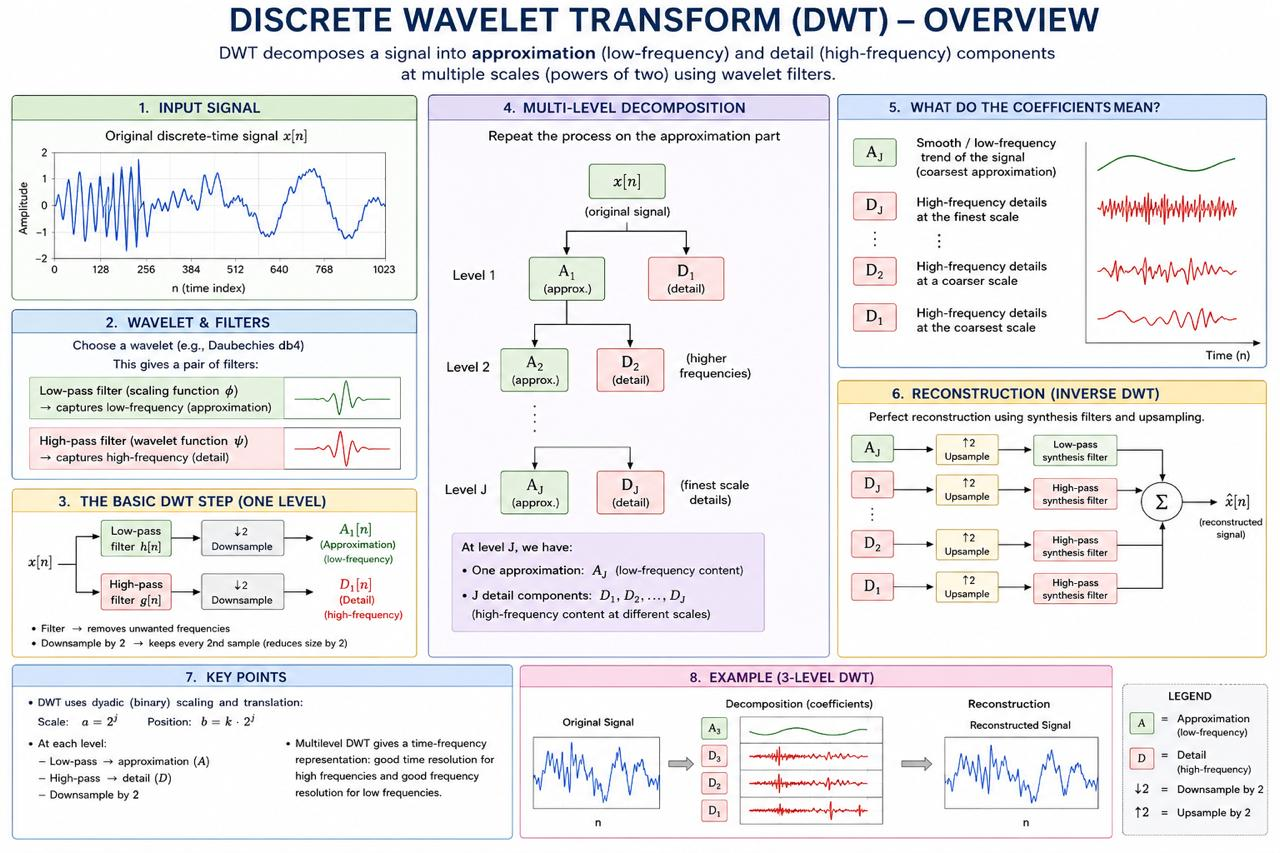

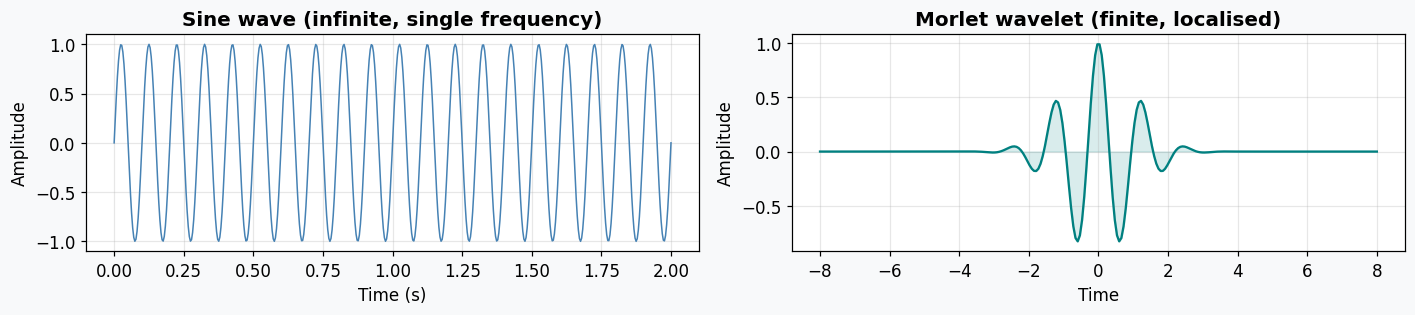

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy import signal as sig
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#f8f9fa', 'axes.facecolor': '#ffffff',
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'figure.dpi': 110,
})

# --- Fourier vs Wavelet: localisation demo ---
fs = 256
t = np.linspace(0, 2, fs * 2)

# A sine wave extends forever; a wavelet is localised
sine = np.sin(2 * np.pi * 10 * t)
wavelet_eg = pywt.ContinuousWavelet('morl')
[psi, x] = wavelet_eg.wavefun()

fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].plot(t, sine, color='steelblue', lw=1)
axes[0].set_title('Sine wave (infinite, single frequency)')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude')

axes[1].plot(x, psi, color='teal', lw=1.5)
axes[1].fill_between(x, psi, alpha=0.15, color='teal')
axes[1].set_title('Morlet wavelet (finite, localised)')
axes[1].set_xlabel('Time'); axes[1].set_ylabel('Amplitude')
plt.tight_layout(); plt.show()

---
## 2. Mother Wavelet, Scaling & Translation

All wavelets used in the transform are **scaled** and **shifted** versions of a single **mother wavelet** $\psi(t)$:

$$\psi_{a,b}(t) = \frac{1}{\sqrt{a}}\,\psi\!\left(\frac{t - b}{a}\right)$$

| Parameter | Symbol | Role |
|---|---|---|
| **Scale** | $a$ | Stretches/compresses the wavelet. Large $a$ = wide = low frequency. Small $a$ = narrow = high frequency. |
| **Translation** | $b$ | Slides the wavelet along time to localise features. |

**Scale-frequency relationship:**
$$F = \frac{C_f}{a \cdot \Delta t}$$
where $C_f$ is the wavelet's centre frequency and $\Delta t = 1/f_s$.

### Dyadic (Binary) Scaling
For computational efficiency, scales and translations are often powers of two:
- Scale: $a = 2^j$ &ensp; ($j = 1, 2, 3, \ldots$)
- Position: $b = 2^j \cdot m$ &ensp; ($m = 0, 1, 2, \ldots$)

This is the basis of the **Discrete Wavelet Transform (DWT)**.

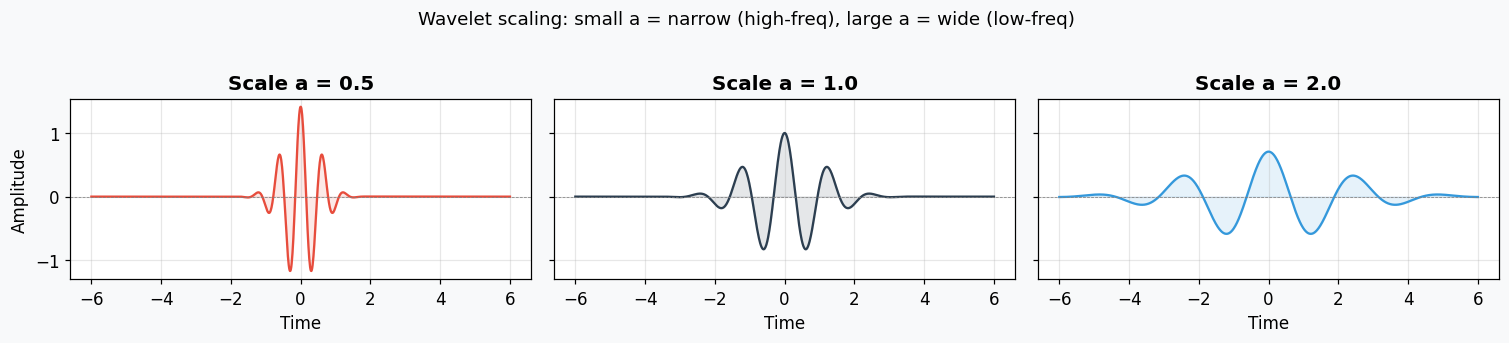

In [3]:
# --- Scaling demo: same Morlet at different scales ---
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)
scales = [0.5, 1.0, 2.0]
colors = ['#e74c3c', '#2c3e50', '#3498db']

t_wav = np.linspace(-6, 6, 1000)
for ax, s, c in zip(axes, scales, colors):
    psi = (1/np.sqrt(s)) * np.cos(5 * t_wav/s) * np.exp(-(t_wav/s)**2 / 2)
    ax.plot(t_wav, psi, color=c, lw=1.5)
    ax.fill_between(t_wav, psi, alpha=0.12, color=c)
    ax.set_title(f'Scale a = {s}')
    ax.set_xlabel('Time')
    ax.axhline(0, color='gray', lw=0.5, ls='--')

axes[0].set_ylabel('Amplitude')
fig.suptitle('Wavelet scaling: small a = narrow (high-freq), large a = wide (low-freq)',
             fontsize=12, y=1.03)
plt.tight_layout(); plt.show()

---
## 3. Number of Cycles & FWHM

The number of cycles in the wavelet controls the **time-frequency trade-off**:

| Cycles | Temporal precision | Frequency precision | Use case |
|---|---|---|---|
| Few (2-6) | High (sharp) | Low (broad) | Transients, edges, spikes |
| Many (10-15) | Low (smeared) | High (narrow) | Steady rhythms |

**EEG rule of thumb:** 3 cycles for gamma (fast transients), 10 cycles for alpha (steady rhythms).

### Full Width at Half Maximum (FWHM)
FWHM measures the width of the wavelet's frequency response at half its peak amplitude.

1. Normalise the power spectrum to [0, 1]
2. Find the two frequencies where power = 0.5
3. $\text{FWHM} = f_{\text{after}} - f_{\text{before}}$

**Guideline:** FWHM should be $\geq$ 1 cycle of the wavelet's centre frequency (e.g. for 10 Hz, FWHM $\geq$ 100 ms).

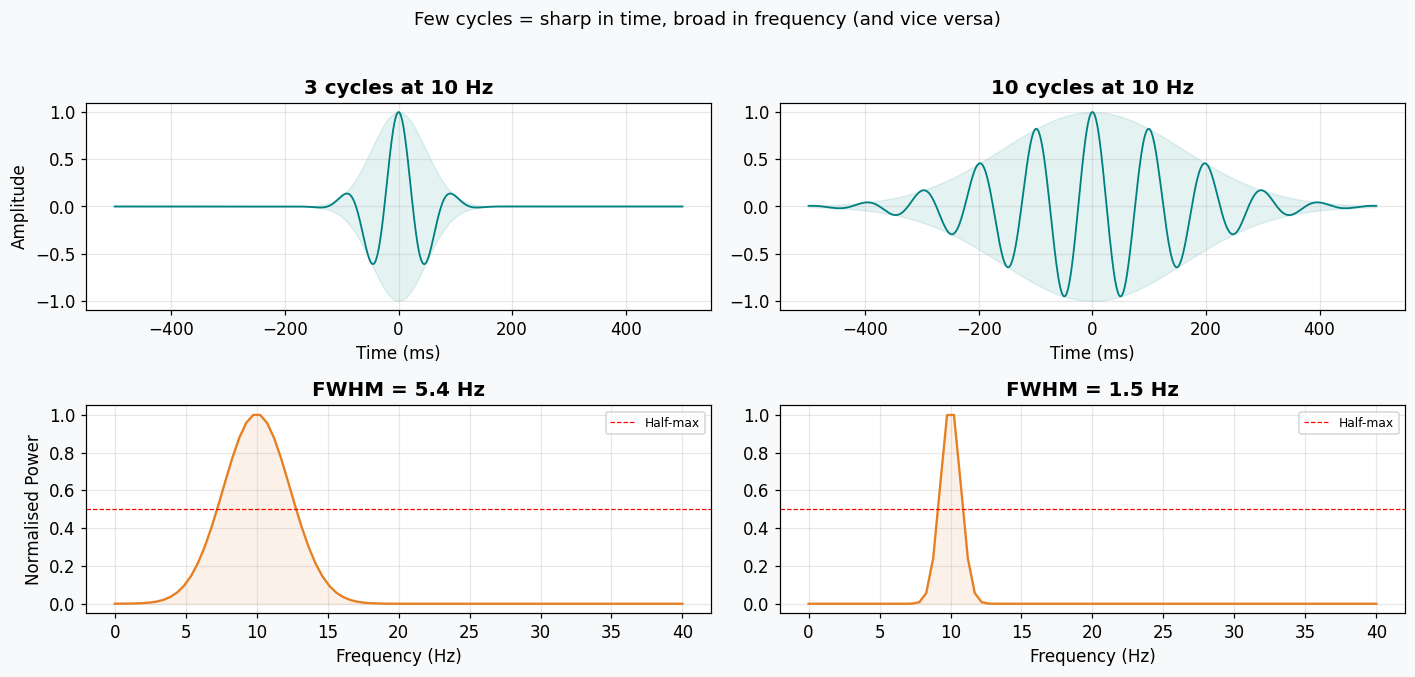

In [4]:
# --- Cycles trade-off: few vs many cycles ---
fig, axes = plt.subplots(2, 2, figsize=(13, 6))

f0 = 10  # centre frequency
for col, n_cycles in enumerate([3, 10]):
    sigma = n_cycles / (2 * np.pi * f0)
    t_w = np.linspace(-0.5, 0.5, 1000)
    wavelet = np.exp(2j * np.pi * f0 * t_w) * np.exp(-t_w**2 / (2 * sigma**2))
    
    # Time domain
    axes[0, col].plot(t_w * 1000, wavelet.real, color='teal', lw=1.2)
    axes[0, col].fill_between(t_w * 1000,
                               np.abs(wavelet), -np.abs(wavelet),
                               alpha=0.1, color='teal')
    axes[0, col].set_title(f'{n_cycles} cycles at {f0} Hz')
    axes[0, col].set_xlabel('Time (ms)')
    
    # Frequency domain
    N = 2048
    W = np.fft.fft(wavelet.real, N)
    freqs = np.fft.fftfreq(N, d=t_w[1]-t_w[0])
    mask = (freqs >= 0) & (freqs <= 40)
    power = np.abs(W[mask])**2
    power /= power.max()
    
    axes[1, col].plot(freqs[mask], power, color='#e67e22', lw=1.5)
    axes[1, col].axhline(0.5, color='red', ls='--', lw=0.8, label='Half-max')
    axes[1, col].fill_between(freqs[mask], power, alpha=0.1, color='#e67e22')
    axes[1, col].set_xlabel('Frequency (Hz)')
    axes[1, col].legend(fontsize=8)
    
    # Calculate FWHM
    above = freqs[mask][power >= 0.5]
    if len(above) > 1:
        fwhm = above[-1] - above[0]
        axes[1, col].set_title(f'FWHM = {fwhm:.1f} Hz')

axes[0, 0].set_ylabel('Amplitude')
axes[1, 0].set_ylabel('Normalised Power')
fig.suptitle('Few cycles = sharp in time, broad in frequency (and vice versa)',
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

---
## 4. Wavelet Families

| Wavelet | Characteristics |
|---|---|
| **Haar** | Simplest; piecewise constant, discontinuous. Fast but poor frequency resolution. |
| **Daubechies (dbN)** | Orthogonal, compact support. Balances smoothness & locality. Most common for EEG. |
| **Symlets (symN)** | Nearly symmetric Daubechies. Reduces phase distortion. |
| **Coiflets (coifN)** | Like Daubechies but with vanishing moments for both wavelet and scaling functions. |
| **Biorthogonal** | Asymmetric analysis/reconstruction pair. Used in image compression (JPEG 2000). |
| **Morlet** | Complex-valued: sine modulated by Gaussian. Ideal for time-frequency analysis (CWT). |
| **Mexican Hat** | Second derivative of Gaussian (Ricker wavelet). Good for edge/spike detection. |

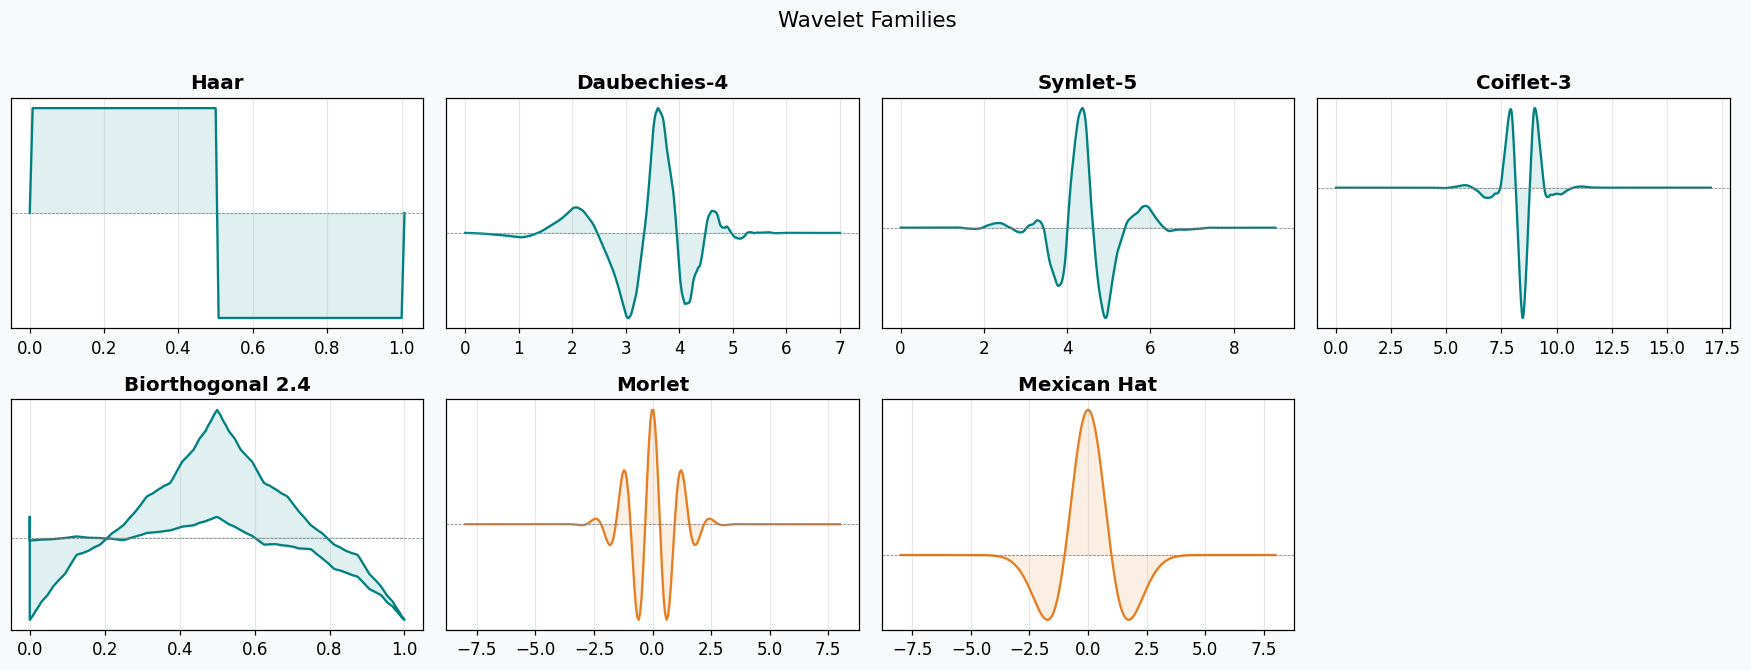

In [6]:
# --- Plot all wavelet families ---
discrete_wavelets = [
    ('haar', 'Haar'),
    ('db4', 'Daubechies-4'),
    ('sym5', 'Symlet-5'),
    ('coif3', 'Coiflet-3'),
    ('bior2.4', 'Biorthogonal 2.4'),
]
continuous_wavelets = [
    ('morl', 'Morlet'),
    ('mexh', 'Mexican Hat'),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, (name, label) in enumerate(discrete_wavelets):
    wav = pywt.Wavelet(name)
    phi, psi, x = wav.wavefun(level=7)[:3]
    axes[i].plot(x, psi, color='teal', lw=1.5)
    axes[i].fill_between(x, psi, alpha=0.12, color='teal')
    axes[i].axhline(0, color='gray', lw=0.5, ls='--')
    axes[i].set_title(label)
    axes[i].set_yticks([])

for j, (name, label) in enumerate(continuous_wavelets):
    wav = pywt.ContinuousWavelet(name)
    psi, x = wav.wavefun()
    idx = len(discrete_wavelets) + j
    axes[idx].plot(x, psi, color='#e67e22', lw=1.5)
    axes[idx].fill_between(x, psi, alpha=0.12, color='#e67e22')
    axes[idx].axhline(0, color='gray', lw=0.5, ls='--')
    axes[idx].set_title(label)
    axes[idx].set_yticks([])

axes[-1].axis('off')  # hide extra subplot
fig.suptitle('Wavelet Families', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### The Morlet Wavelet (closer look)

The Morlet is a complex-valued wavelet: a sine wave (carrier) inside a Gaussian envelope:

$$\psi(t) = e^{i\omega_0 t} \cdot e^{-t^2/2}$$

- $\omega_0$: centre frequency of the carrier
- The Gaussian envelope localises it in time
- Acts as a **band-pass filter** when convolved with a signal
- Widely used in neuroscience for EEG time-frequency analysis

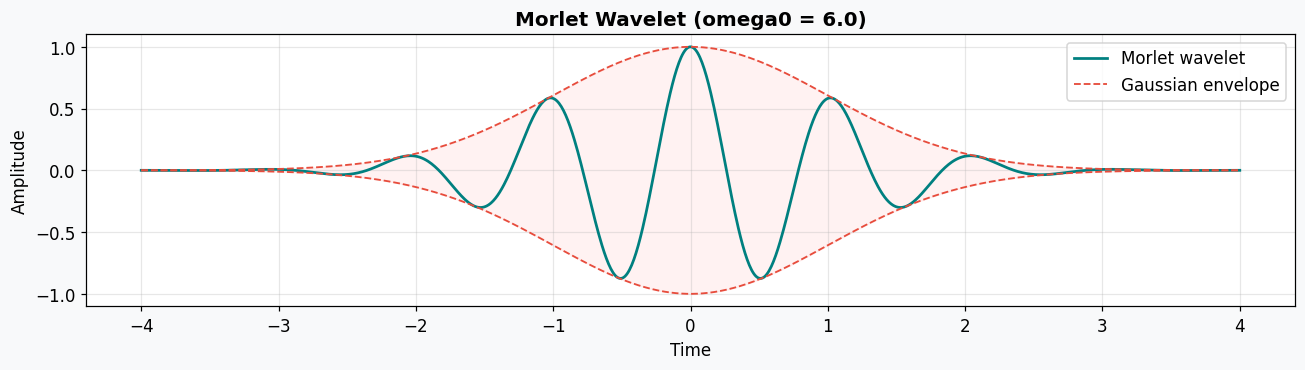

In [7]:
# --- Morlet wavelet anatomy ---
t_m = np.linspace(-4, 4, 1000)
omega0 = 6.0
carrier = np.cos(omega0 * t_m)
envelope = np.exp(-t_m**2 / 2)
morlet = carrier * envelope

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(t_m, morlet, color='teal', lw=1.8, label='Morlet wavelet')
ax.plot(t_m, envelope, color='#e74c3c', lw=1.2, ls='--', label='Gaussian envelope')
ax.plot(t_m, -envelope, color='#e74c3c', lw=1.2, ls='--')
ax.fill_between(t_m, envelope, -envelope, alpha=0.05, color='red')
ax.set_title(f'Morlet Wavelet (omega0 = {omega0})')
ax.set_xlabel('Time'); ax.set_ylabel('Amplitude')
ax.legend(); plt.tight_layout(); plt.show()

---
## 5. Types of Wavelet Transform

| Transform | Description | Key property |
|---|---|---|
| **CWT** (Continuous) | All possible scales; dense time-frequency map (scalogram) | High resolution, redundant |
| **DWT** (Discrete) | Dyadic scales only; fast ($O(N)$); outputs approximation + detail coefficients | Efficient, non-redundant |
| **SWT** (Stationary) | Like DWT but without downsampling; shift-invariant | Better for denoising |
| **MRA** (Multiresolution) | Hierarchical decomposition into low-pass (approximation) and high-pass (detail) at each level | Feature extraction |

### Workflow
1. Choose a wavelet (e.g. db4 for denoising, Morlet for time-frequency)
2. Set scales (or decomposition level)
3. Compute the transform
4. Analyse / threshold / reconstruct

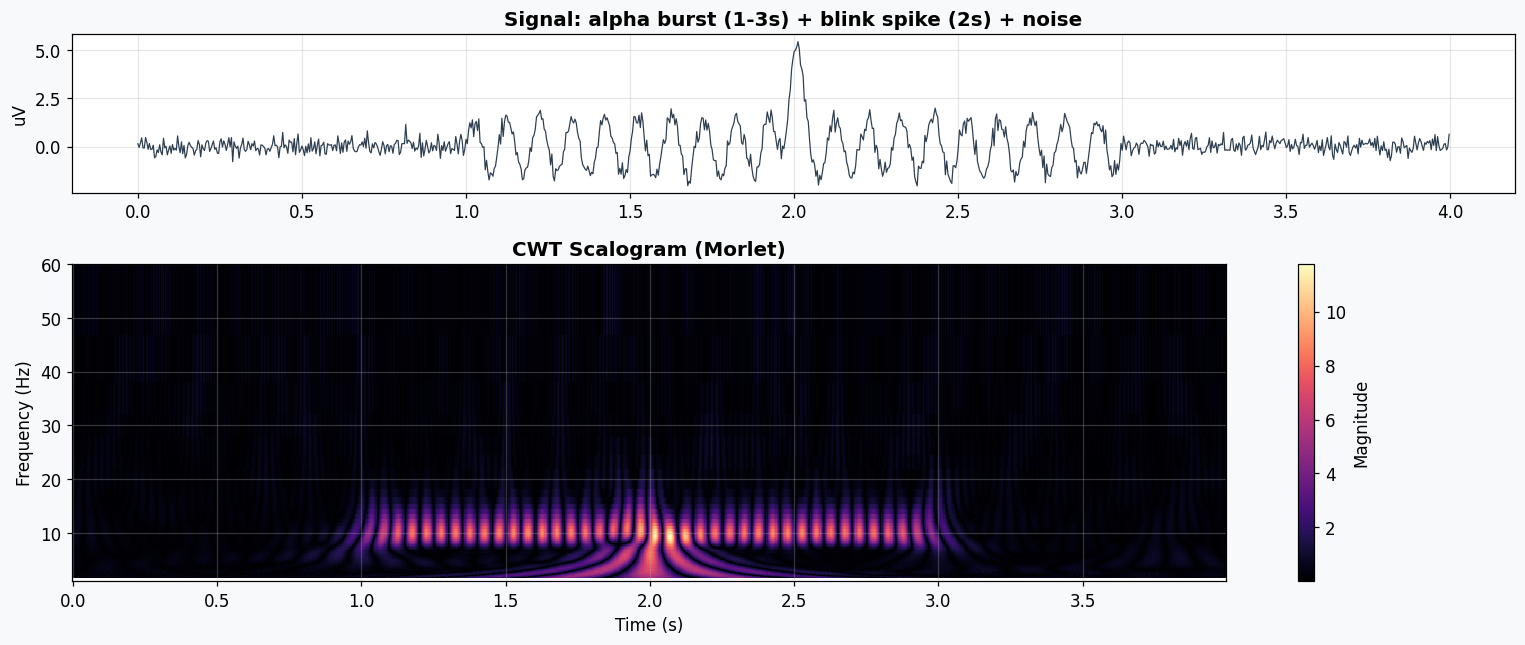

In [8]:
# --- CWT Scalogram ---
np.random.seed(42)
fs = 256; dur = 4
t = np.arange(0, dur, 1/fs)

# Signal: alpha that appears at t=1-3s, plus a blink spike at t=2s
signal = np.zeros_like(t)
signal += np.where((t >= 1) & (t <= 3), 1.5 * np.sin(2*np.pi*10*t), 0)  # alpha burst
signal += 5 * np.exp(-((t - 2.0)**2) / (2 * 0.02**2))  # blink
signal += 0.3 * np.random.randn(len(t))

# CWT
scales = np.arange(1, 128)
coefficients, frequencies = pywt.cwt(signal, scales, 'morl', sampling_period=1/fs)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={'height_ratios': [1, 2]})

axes[0].plot(t, signal, color='#2c3e50', lw=0.8)
axes[0].set_title('Signal: alpha burst (1-3s) + blink spike (2s) + noise')
axes[0].set_ylabel('uV')

im = axes[1].pcolormesh(t, frequencies, np.abs(coefficients), cmap='magma', shading='auto')
axes[1].set_ylim(1, 60)
axes[1].set_title('CWT Scalogram (Morlet)')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Frequency (Hz)')
plt.colorbar(im, ax=axes[1], label='Magnitude')
plt.tight_layout(); plt.show()

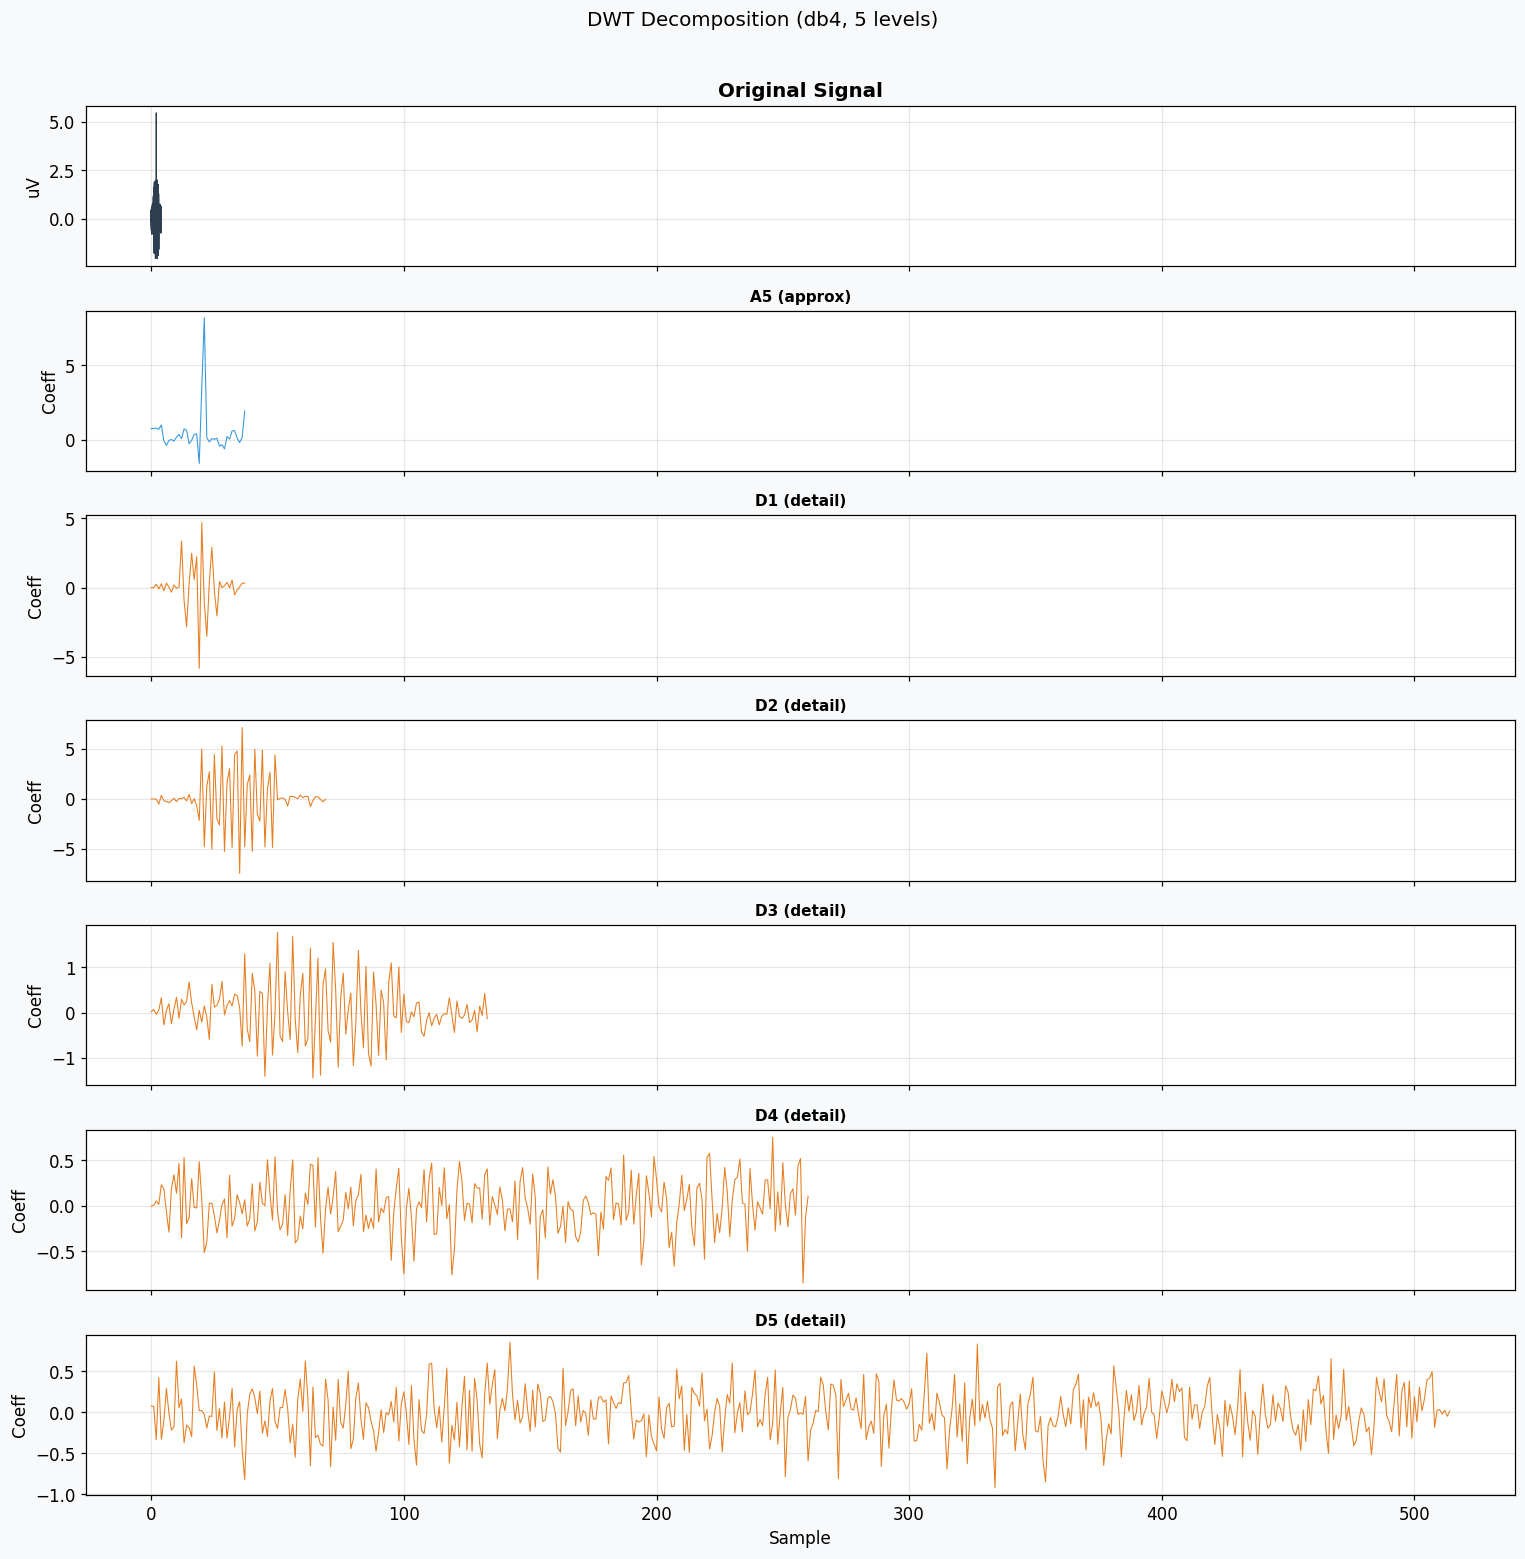

Sampling rate: 256 Hz
  D1: 64.0 - 128.0 Hz
  D2: 32.0 - 64.0 Hz
  D3: 16.0 - 32.0 Hz
  D4: 8.0 - 16.0 Hz
  D5: 4.0 - 8.0 Hz
  A5: 0 - 4.0 Hz


In [34]:
# --- DWT Multiresolution Decomposition ---
wavelet = 'db4'
level = 5
coeffs = pywt.wavedec(signal, wavelet, level=level)

fig, axes = plt.subplots(level + 2, 1, figsize=(14, 2 * (level + 2)), sharex=True)

axes[0].plot(t, signal, color='#2c3e50', lw=0.8)
axes[0].set_title('Original Signal')
axes[0].set_ylabel('uV')

labels = [f'A{level} (approx)'] + [f'D{i} (detail)' for i in range(1, level + 1)]
colors = ['#3498db'] + ['#e67e22'] * level

for i, (c, label, col) in enumerate(zip(coeffs, labels, colors)):
    ax = axes[i + 1]
    ax.plot(c, color=col, lw=0.7)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Coeff')

axes[-1].set_xlabel('Sample')
fig.suptitle(f'DWT Decomposition ({wavelet}, {level} levels)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

# Show frequency bands
print(f'Sampling rate: {fs} Hz')
for i in range(level):
    lo = fs / 2**(i+2)
    hi = fs / 2**(i+1)
    print(f'  D{i+1}: {lo:.1f} - {hi:.1f} Hz')
print(f'  A{level}: 0 - {fs/2**(level+1):.1f} Hz')

---
## 6. Wavelet Denoising

Denoising works by **thresholding wavelet coefficients**: small coefficients (noise-dominated) are shrunk or zeroed, large ones (signal) are kept.

### Thresholding modes
- **Hard:** zero out coefficients below threshold; keep the rest unchanged
- **Soft:** shrink all coefficients toward zero by the threshold amount (smoother)

### Threshold selection methods

| Method | Formula / Idea | Strength |
|---|---|---|
| **Universal (VisuShrink)** | $\lambda = \hat{\sigma} \sqrt{2 \log n}$, where $\hat{\sigma} = \text{MAD}(d_1) / 0.6745$ | Simple, conservative (tends to over-smooth) |
| **SURE (SureShrink)** | Minimises Stein's Unbiased Risk Estimate per level | Adaptive, better for non-uniform noise |
| **Minimax** | Optimises worst-case risk over all signals in a class | Robust, good when you don't know the noise structure |

Let's test all three on a synthetic noisy EEG.

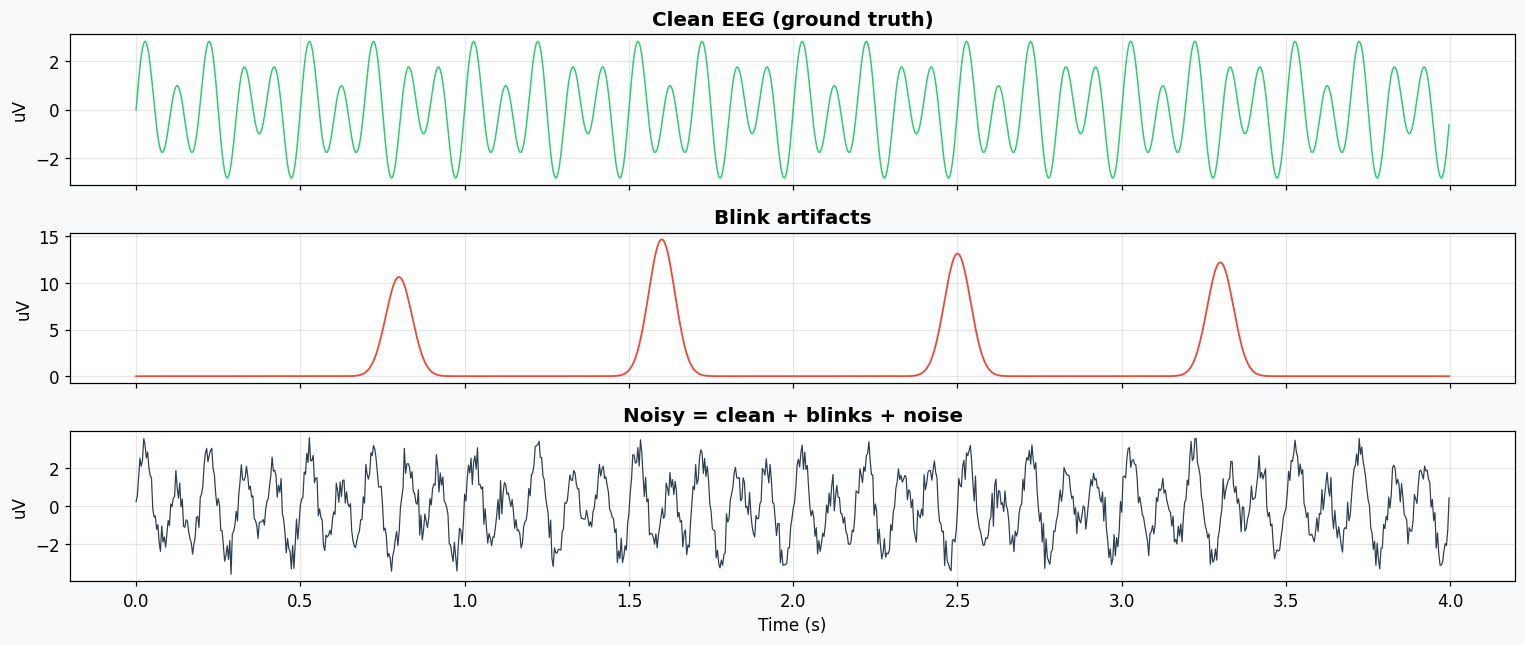

In [20]:
# --- Build synthetic test signal ---
np.random.seed(42)
fs = 256; dur = 4
t = np.arange(0, dur, 1/fs)
N = len(t)

# Clean EEG: alpha + theta + light background
clean = 2.0 * np.sin(2*np.pi*10*t) + 1.0 * np.sin(2*np.pi*6*t)

# # Blink artifacts
# blinks = np.zeros(N)
# for bt in [0.8, 1.6, 2.5, 3.3]:
#     blinks += np.random.uniform(8, 15) * np.exp(-0.5*((t - bt)/(0.04))**2)

noise = 0.5 * np.random.randn(N)
noisy = clean + noise

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
axes[0].plot(t, clean, color='#2ecc71', lw=1); axes[0].set_title('Clean EEG (ground truth)')
axes[1].plot(t, blinks, color='#e74c3c', lw=1.2); axes[1].set_title('Blink artifacts')
axes[2].plot(t, noisy, color='#2c3e50', lw=0.8); axes[2].set_title('Noisy = clean + blinks + noise')
for ax in axes: ax.set_ylabel('uV')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

In [21]:
# ── Threshold computation helpers ───────────────────────────────────────────

def _sigma_mad(detail_coeffs):
    """Noise std estimate from finest detail coefficients (MAD)."""
    return np.median(np.abs(detail_coeffs)) / 0.6745


def threshold_universal(coeffs):
    """VisuShrink: lambda = sigma * sqrt(2 * log(n))."""
    sigma = _sigma_mad(coeffs[-1])
    n = sum(len(c) for c in coeffs)
    lam = sigma * np.sqrt(2 * np.log(n))
    return lam


def threshold_sure_level(c, sigma):
    """SURE threshold for a single coefficient vector."""
    n = len(c)
    if n < 2:
        return 0.0
    c_abs = np.sort(np.abs(c))
    # Compute SURE risk for each candidate threshold
    risks = np.zeros(n)
    for i in range(n):
        lam = c_abs[i]
        risks[i] = (n - 2 * (i + 1) + np.sum(np.minimum(c_abs**2, lam**2))) / n
    best = c_abs[np.argmin(risks)]
    # SureShrink: take min(SURE threshold, universal threshold)
    universal = sigma * np.sqrt(2 * np.log(n))
    return min(best, universal)


def threshold_minimax(n, sigma):
    """Minimax threshold."""
    if n <= 32:
        return 0.0  # no thresholding for very short signals
    return sigma * (0.3936 + 0.1829 * np.log2(n))


print('Threshold functions defined.')

Threshold functions defined.


In [22]:
# ── Apply all three denoising methods ───────────────────────────────────────

wavelet = 'db4'
level = 7
coeffs = pywt.wavedec(noisy, wavelet, level=level)
sigma = _sigma_mad(coeffs[-1])


def denoise(coeffs, method, sigma, wavelet):
    """Apply thresholding to detail coefficients and reconstruct."""
    out = [coeffs[0]]  # keep approximation
    for i, c in enumerate(coeffs[1:]):
        if method == 'universal':
            lam = threshold_universal(coeffs)
        elif method == 'sure':
            lam = threshold_sure_level(c, sigma)
        elif method == 'minimax':
            lam = threshold_minimax(len(c), sigma)
        out.append(pywt.threshold(c, lam, mode='soft'))
    return pywt.waverec(out, wavelet)[:N]


results = {}
for method in ['universal', 'sure', 'minimax']:
    recon = denoise(coeffs, method, sigma, wavelet)
    rmse = np.sqrt(np.mean((clean - recon)**2))
    r, _ = pearsonr(clean, recon)
    results[method] = {'recon': recon, 'rmse': rmse, 'r': r}
    print(f'{method:>10s}:  RMSE = {rmse:.4f},  R = {r:.4f}')

 universal:  RMSE = 0.6108,  R = 0.9572
      sure:  RMSE = 0.3543,  R = 0.9758
   minimax:  RMSE = 0.3659,  R = 0.9786


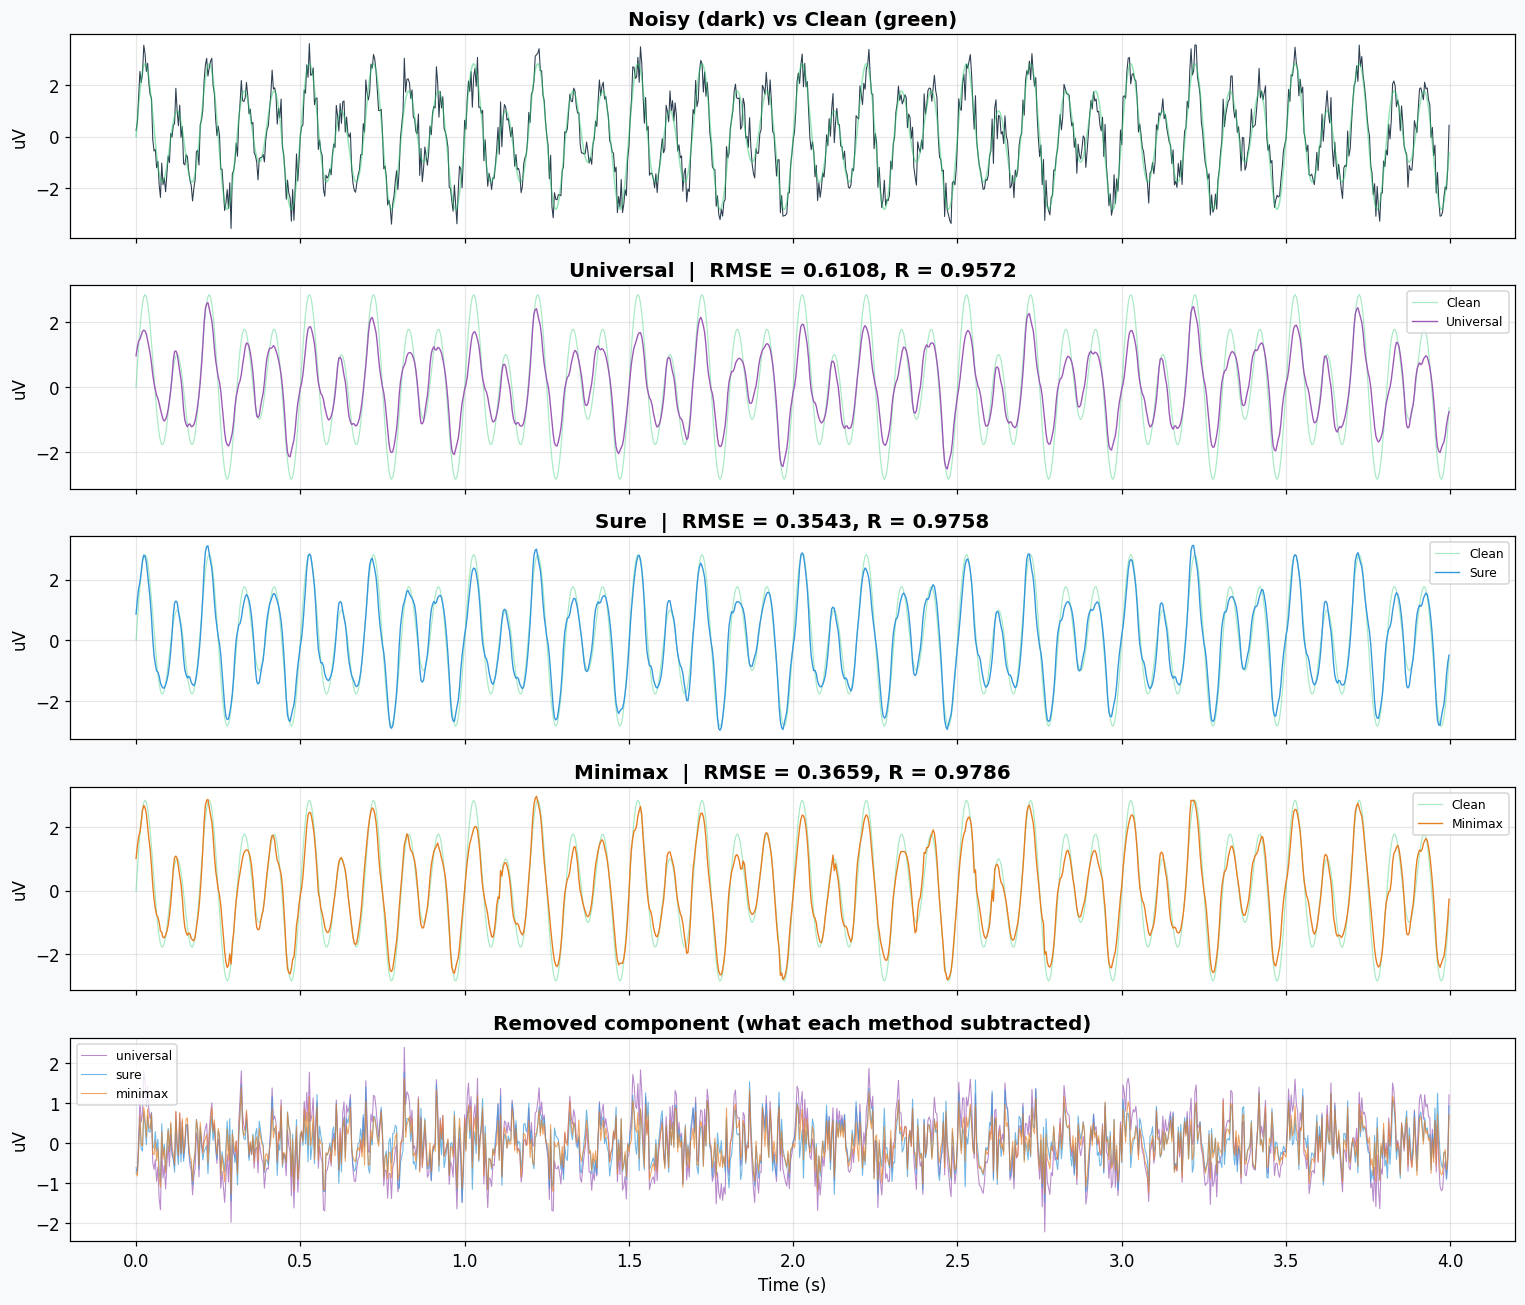

In [23]:
# ── Visual comparison ───────────────────────────────────────────────────────
method_colors = {'universal': '#9b59b6', 'sure': '#3498db', 'minimax': '#e67e22'}

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t, noisy, color='#2c3e50', lw=0.7)
axes[0].plot(t, clean, color='#2ecc71', lw=1, alpha=0.5)
axes[0].set_title('Noisy (dark) vs Clean (green)'); axes[0].set_ylabel('uV')

for i, (method, res) in enumerate(results.items()):
    ax = axes[i + 1]
    ax.plot(t, clean, color='#2ecc71', lw=0.8, alpha=0.4, label='Clean')
    ax.plot(t, res['recon'], color=method_colors[method], lw=0.9, label=method.capitalize())
    ax.set_title(f'{method.capitalize()}  |  RMSE = {res["rmse"]:.4f}, R = {res["r"]:.4f}')
    ax.set_ylabel('uV'); ax.legend(loc='upper right', fontsize=8)

# Residuals
ax = axes[4]
for method, res in results.items():
    ax.plot(t, noisy - res['recon'], color=method_colors[method], lw=0.7, alpha=0.7, label=method)
ax.set_title('Removed component (what each method subtracted)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('uV'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

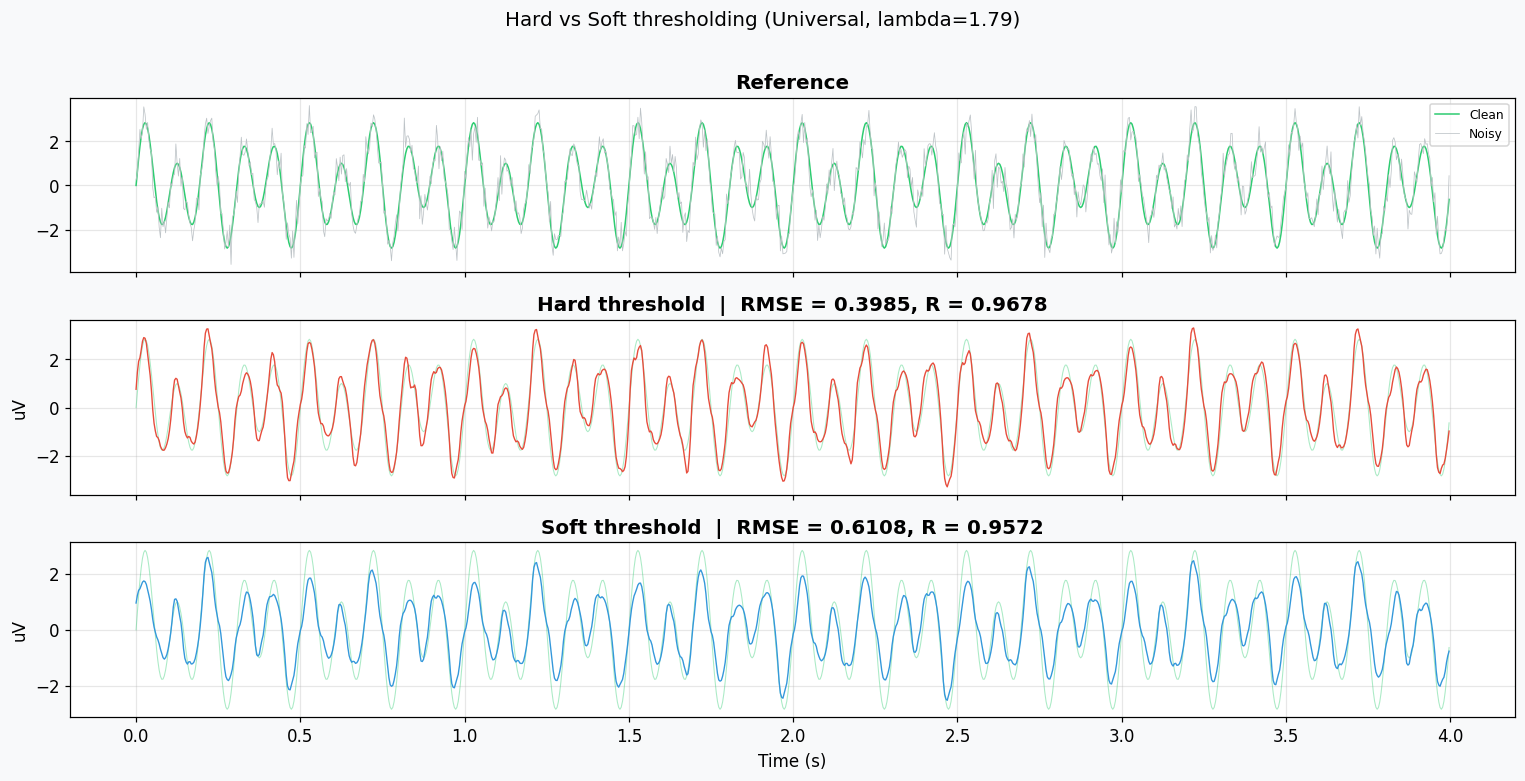

In [24]:
# ── Hard vs Soft thresholding comparison ────────────────────────────────────
lam = threshold_universal(coeffs)

def denoise_mode(coeffs, lam, mode, wavelet):
    out = [coeffs[0]]
    for c in coeffs[1:]:
        out.append(pywt.threshold(c, lam, mode=mode))
    return pywt.waverec(out, wavelet)[:N]

hard_recon = denoise_mode(coeffs, lam, 'hard', wavelet)
soft_recon = denoise_mode(coeffs, lam, 'soft', wavelet)

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

axes[0].plot(t, clean, color='#2ecc71', lw=1, label='Clean')
axes[0].plot(t, noisy, color='#bdc3c7', lw=0.5, label='Noisy')
axes[0].set_title('Reference'); axes[0].legend(fontsize=8)

for ax, recon, mode, col in [(axes[1], hard_recon, 'Hard', '#e74c3c'),
                               (axes[2], soft_recon, 'Soft', '#3498db')]:
    rmse = np.sqrt(np.mean((clean - recon)**2))
    r, _ = pearsonr(clean, recon)
    ax.plot(t, clean, color='#2ecc71', lw=0.7, alpha=0.4)
    ax.plot(t, recon, color=col, lw=0.9)
    ax.set_title(f'{mode} threshold  |  RMSE = {rmse:.4f}, R = {r:.4f}')
    ax.set_ylabel('uV')

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Hard vs Soft thresholding (Universal, lambda={lam:.2f})', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

---
## 7. Effect of Wavelet Choice on Denoising

Different mother wavelets produce different results. Let's test several on the same noisy signal.

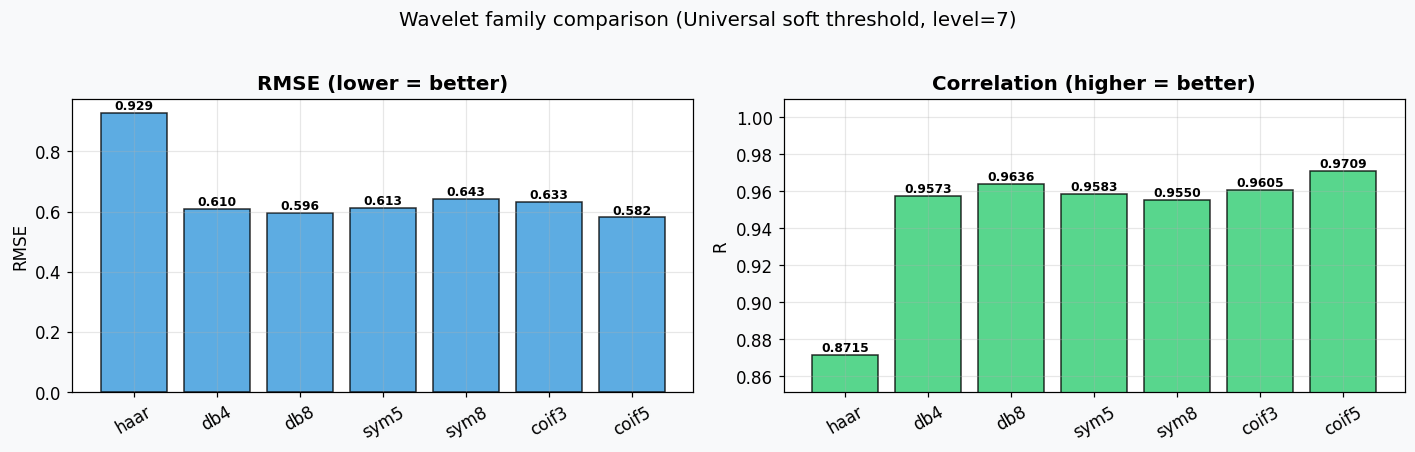

In [25]:
# ── Compare wavelet families for denoising ──────────────────────────────────
test_wavelets = ['haar', 'db4', 'db8', 'sym5', 'sym8', 'coif3', 'coif5']
level = 7

wav_results = {}
for wname in test_wavelets:
    c = pywt.wavedec(noisy, wname, level=level)
    s = _sigma_mad(c[-1])
    lam = s * np.sqrt(2 * np.log(N))
    out = [c[0]] + [pywt.threshold(d, lam, mode='soft') for d in c[1:]]
    recon = pywt.waverec(out, wname)[:N]
    rmse = np.sqrt(np.mean((clean - recon)**2))
    r, _ = pearsonr(clean, recon)
    wav_results[wname] = {'recon': recon, 'rmse': rmse, 'r': r}

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
names = list(wav_results.keys())
rmses = [wav_results[n]['rmse'] for n in names]
rs = [wav_results[n]['r'] for n in names]

bars = axes[0].bar(names, rmses, color='#3498db', edgecolor='k', alpha=0.8)
for b, v in zip(bars, rmses):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}',
                 ha='center', fontsize=8, fontweight='bold')
axes[0].set_ylabel('RMSE'); axes[0].set_title('RMSE (lower = better)')
axes[0].tick_params(axis='x', rotation=30)

bars = axes[1].bar(names, rs, color='#2ecc71', edgecolor='k', alpha=0.8)
for b, v in zip(bars, rs):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.002, f'{v:.4f}',
                 ha='center', fontsize=8, fontweight='bold')
axes[1].set_ylabel('R'); axes[1].set_title('Correlation (higher = better)')
axes[1].set_ylim(min(rs) - 0.02, 1.01)
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('Wavelet family comparison (Universal soft threshold, level=7)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 8. Effect of Decomposition Level

Too few levels = can't separate low-frequency artifacts from signal. Too many = risk distorting slow components.

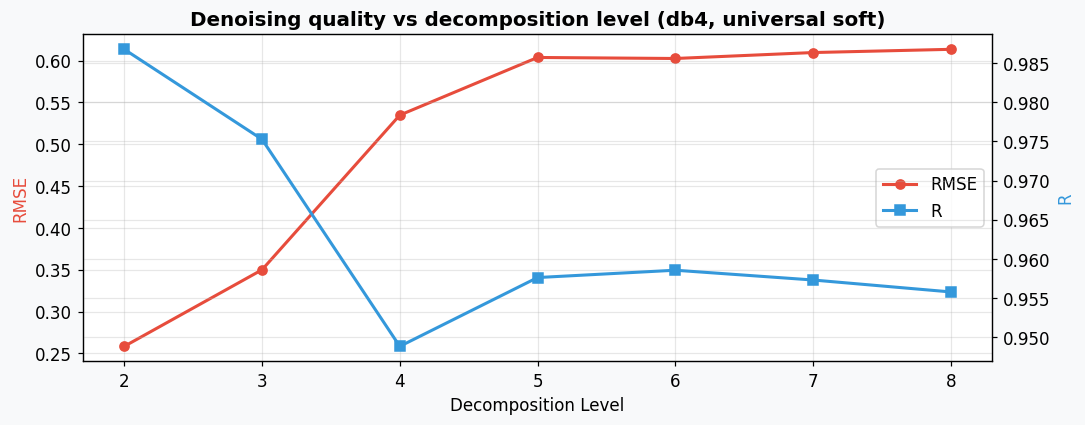

In [26]:
# ── Level sweep ─────────────────────────────────────────────────────────────
levels = range(2, 9)
level_rmse, level_r = [], []

for lev in levels:
    c = pywt.wavedec(noisy, 'db4', level=lev)
    s = _sigma_mad(c[-1])
    lam = s * np.sqrt(2 * np.log(N))
    out = [c[0]] + [pywt.threshold(d, lam, mode='soft') for d in c[1:]]
    recon = pywt.waverec(out, 'db4')[:N]
    level_rmse.append(np.sqrt(np.mean((clean - recon)**2)))
    r, _ = pearsonr(clean, recon)
    level_r.append(r)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(list(levels), level_rmse, 'o-', color='#e74c3c', lw=2, label='RMSE')
ax2.plot(list(levels), level_r, 's-', color='#3498db', lw=2, label='R')

ax1.set_xlabel('Decomposition Level'); ax1.set_ylabel('RMSE', color='#e74c3c')
ax2.set_ylabel('R', color='#3498db')
ax1.set_title('Denoising quality vs decomposition level (db4, universal soft)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.tight_layout(); plt.show()

---
## 9. Applications Beyond Denoising

### Compression
Most DWT coefficients are small and can be zeroed out without significant information loss. By keeping only the largest $k\%$ of coefficients, you achieve high compression ratios.

### Feature Extraction & Anomaly Detection
- **Feature extraction:** Wavelets isolate localised features (edges, rhythmic patterns, transients). Band-specific energy from each decomposition level is a common EEG feature vector.
- **Anomaly detection:** Detect deviations from expected patterns (faults in sensors, arrhythmias in ECG, seizure onset in EEG) by monitoring coefficient magnitudes at relevant scales.

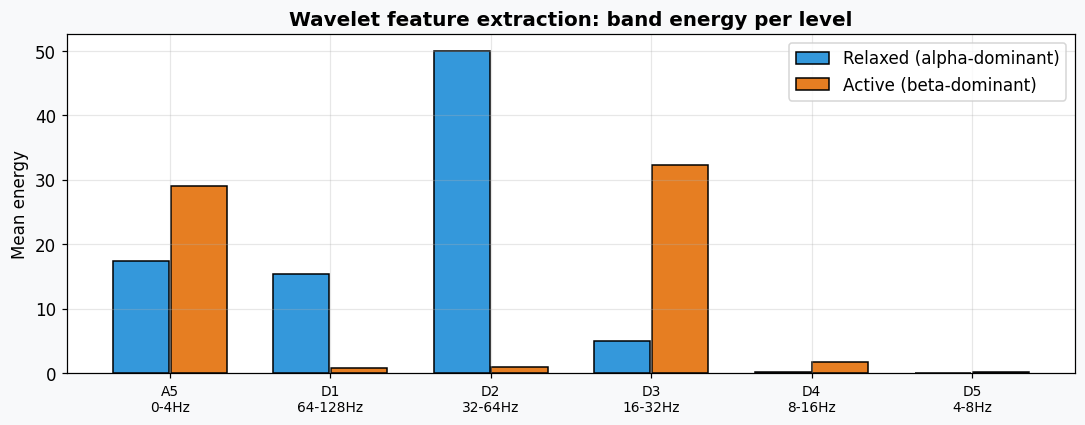

In [27]:
# ── Feature extraction: band energy per decomposition level ─────────────────
np.random.seed(7)
fs = 256; t_fe = np.arange(0, 4, 1/fs)

# Two "conditions": relaxed (strong alpha) vs active (strong beta)
relaxed = 3 * np.sin(2*np.pi*10*t_fe) + 0.5 * np.sin(2*np.pi*22*t_fe) + 0.3*np.random.randn(len(t_fe))
active  = 0.5 * np.sin(2*np.pi*10*t_fe) + 3 * np.sin(2*np.pi*22*t_fe) + 0.3*np.random.randn(len(t_fe))

def band_energies(x, wavelet='db4', level=5):
    c = pywt.wavedec(x, wavelet, level=level)
    return [np.sum(ci**2) / len(ci) for ci in c]

e_relax = band_energies(relaxed)
e_active = band_energies(active)

labels_fe = [f'A{5}\n0-{fs/2**6:.0f}Hz'] + [f'D{i}\n{fs/2**(i+1):.0f}-{fs/2**i:.0f}Hz' for i in range(1, 6)]

x_pos = np.arange(len(labels_fe))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x_pos - 0.18, e_relax, 0.35, label='Relaxed (alpha-dominant)', color='#3498db', edgecolor='k')
ax.bar(x_pos + 0.18, e_active, 0.35, label='Active (beta-dominant)', color='#e67e22', edgecolor='k')
ax.set_xticks(x_pos); ax.set_xticklabels(labels_fe, fontsize=9)
ax.set_ylabel('Mean energy'); ax.set_title('Wavelet feature extraction: band energy per level')
ax.legend(); plt.tight_layout(); plt.show()

---
## 10. Putting It Together: WT Denoising on Real-like EEG

Final demo: apply all three threshold methods + compare wavelet choices on a longer, more realistic synthetic EEG with multiple artifact types.

 universal:  RMSE = 3.2153,  R = 0.2509
      sure:  RMSE = 3.2066,  R = 0.3423
   minimax:  RMSE = 3.2110,  R = 0.3074


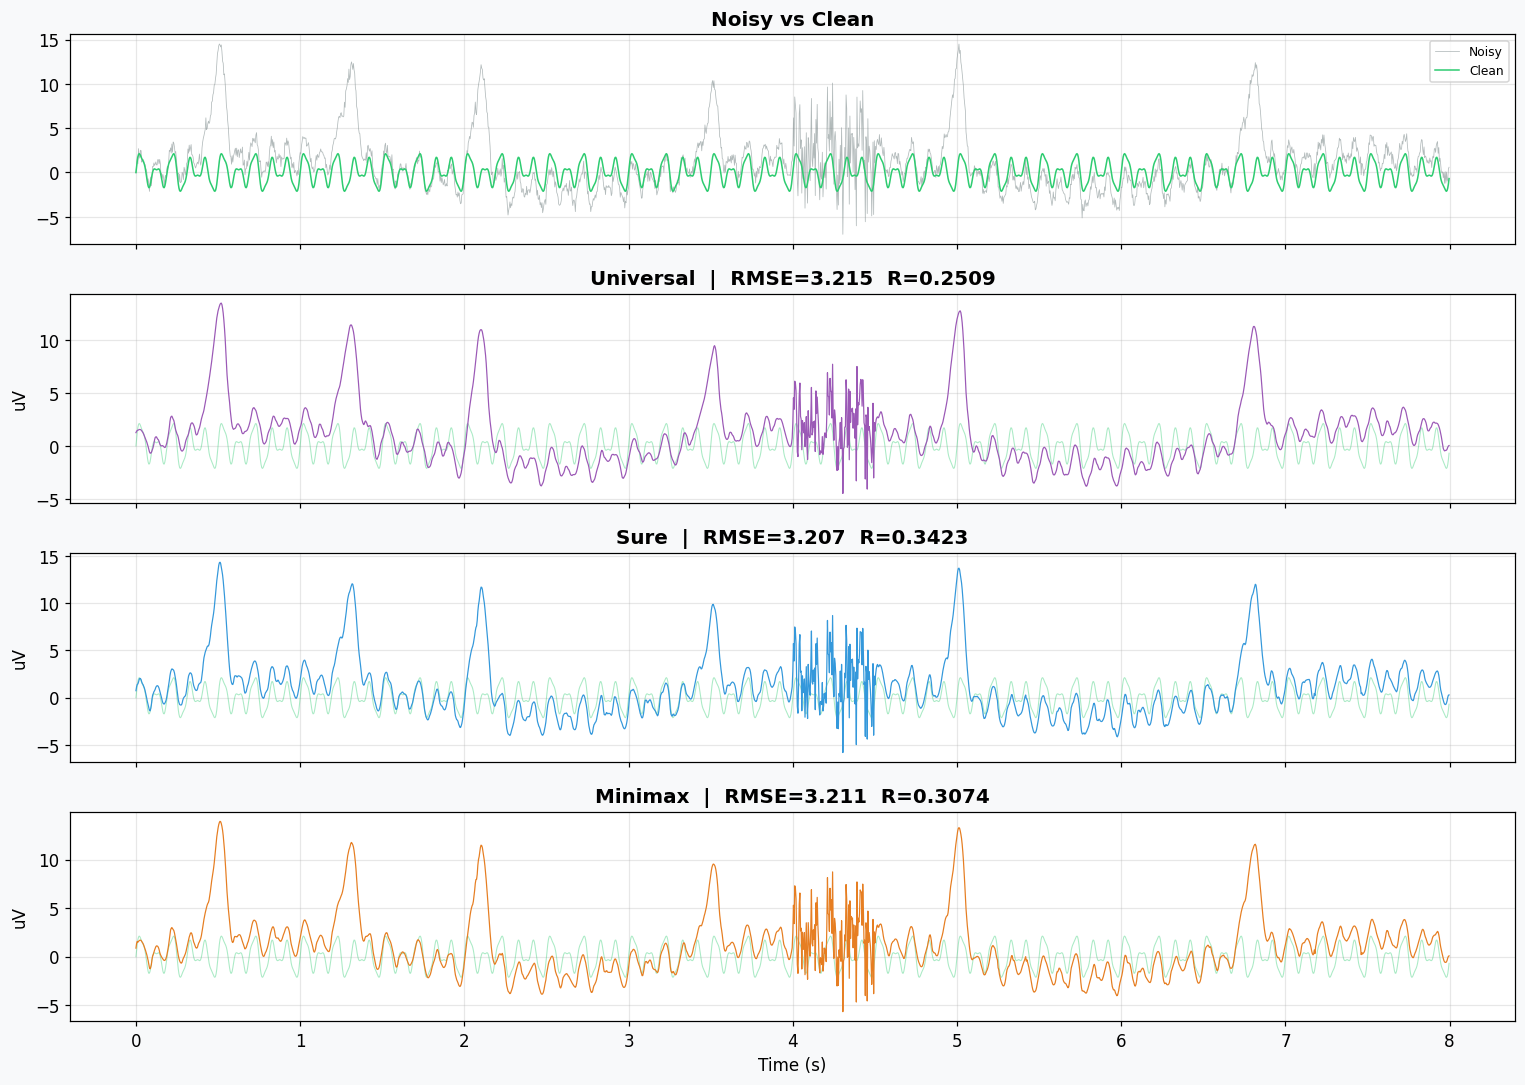

In [33]:
# ── Realistic synthetic EEG ─────────────────────────────────────────────────
np.random.seed(99)
fs = 256; dur = 8
t_r = np.arange(0, dur, 1/fs)
N_r = len(t_r)

# Clean: alpha + theta + beta
clean_r = (1.5 * np.sin(2*np.pi*10*t_r) +
           0.8 * np.sin(2*np.pi*6*t_r) +
           0.4 * np.sin(2*np.pi*22*t_r))

# Artifacts: 6 blinks + muscle burst + slow drift
blinks_r = sum(np.random.uniform(8,14) * np.exp(-0.5*((t_r-bt)/0.04)**2)
               for bt in [0.5, 1.3, 2.1, 3.5, 5.0, 6.8])
muscle = np.where((t_r > 4) & (t_r < 4.5), 3 * np.random.randn(N_r), 0)
drift = 2 * np.sin(2*np.pi*0.3*t_r)

noisy_r = clean_r + blinks_r + muscle + drift + 0.4*np.random.randn(N_r)

# Denoise with all 3 methods
results_r = {}
for method in ['universal', 'sure', 'minimax']:
    c = pywt.wavedec(noisy_r, 'db4', level=4)
    s = _sigma_mad(c[-1])
    out = [c[0]]
    for ci in c[1:]:
        if method == 'universal':
            lam = s * np.sqrt(2 * np.log(N_r))
        elif method == 'sure':
            lam = threshold_sure_level(ci, s)
        elif method == 'minimax':
            lam = threshold_minimax(len(ci), s)
        out.append(pywt.threshold(ci, lam, mode='soft'))
    recon = pywt.waverec(out, 'db4')[:N_r]
    rmse = np.sqrt(np.mean((clean_r - recon)**2))
    r, _ = pearsonr(clean_r, recon)
    results_r[method] = {'recon': recon, 'rmse': rmse, 'r': r}
    print(f'{method:>10s}:  RMSE = {rmse:.4f},  R = {r:.4f}')

# Plot
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(t_r, noisy_r, color='#7f8c8d', lw=0.5, alpha=0.6, label='Noisy')
axes[0].plot(t_r, clean_r, color='#2ecc71', lw=1, label='Clean')
axes[0].set_title('Noisy vs Clean'); axes[0].legend(fontsize=8)

for i, (method, res) in enumerate(results_r.items()):
    ax = axes[i+1]
    ax.plot(t_r, clean_r, color='#2ecc71', lw=0.7, alpha=0.4)
    ax.plot(t_r, res['recon'], color=method_colors[method], lw=0.8)
    ax.set_title(f'{method.capitalize()}  |  RMSE={res["rmse"]:.3f}  R={res["r"]:.4f}')
    ax.set_ylabel('uV')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()

---
## Summary

| Concept | Key takeaway |
|---|---|
| Wavelets vs Fourier | Localised in both time and frequency; ideal for non-stationary signals |
| Scale $a$ | Large = low-freq, Small = high-freq |
| Cycles / FWHM | Trade-off between temporal and frequency precision |
| Wavelet families | db4/sym5 are solid defaults for EEG; Morlet for CWT time-frequency maps |
| CWT vs DWT | CWT = dense scalogram; DWT = fast, used for denoising & compression |
| Denoising | Threshold detail coefficients; Universal is simple, SURE adapts per level, Minimax is robust |
| Hard vs Soft | Soft is smoother (preferred); Hard preserves peaks but adds ringing |
| Compression | Keep only largest $k$% of DWT coefficients |
| Feature extraction | Band energy per decomposition level separates brain states |

DWT (wavedec)	CWT (cwt)
Input wavelet	Discrete only (db4, sym5, haar...)	Continuous only (cmor, morl, mexh...)
Output	List of coefficient arrays (one per level)	2D matrix (scales x time)
Inverse	pywt.waverec	No built-in inverse in pywt
Use case	Denoising, compression	Time-frequency analysis (scalograms)
The cmor wavelet needs bandwidth and centre frequency parameters: 'cmor{B}-{C}', e.g. 'cmor1.5-1.0'. Just 'cmor' will error.

For denoising, stick with DWT (wavedec + db4/sym5). CWT is great for visualising time-frequency content (scalograms) but isn't practical for denoising since pywt doesn't provide cwt inverse reconstruction.

